# Dendrogram

In [4]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
OBJ = "airway-epithelium"
OBJ_V = 'reclustered'
OBJ_PATH= MAIN_DIR / 'data' / 'sub' / OBJ / 'h5ad' / f'{OBJ}-{OBJ_V}.h5ad'

In [5]:
obj = sc.read_h5ad(OBJ_PATH)

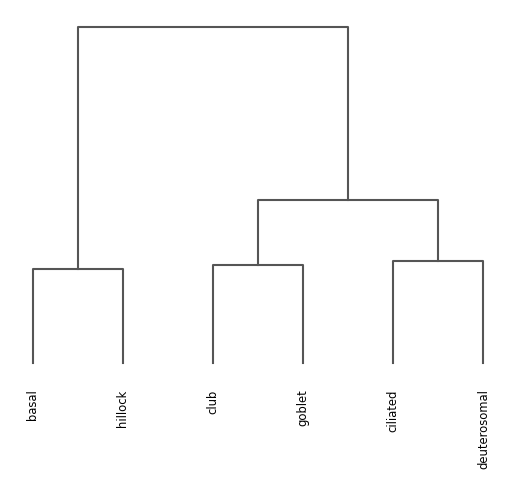

In [6]:

res_name = "reclustered_ct"
dendro_key = f"dendrogram_{res_name}"

sc.tl.dendrogram(
    obj,
    groupby=res_name,
    use_rep="X_resolvi",  # confirm exact key in comb.obsm
    cor_method="pearson",
    linkage_method="complete",
    key_added=dendro_key,
)

ax = sc.pl.dendrogram(
    obj,
    groupby=res_name,
    dendrogram_key=dendro_key,
    show=False,
)